In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/nykaa_campaign_data.csv")

In [3]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


In [4]:
df.shape

(55555, 16)

In [5]:
df.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [7]:
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.446044,55087.885357,4688.070507,1877.271119,1032.866925,5.158197e+05,377.347068,2.713807,13.784169
std,7.520438,25930.001514,3178.686285,1435.636117,862.496788,4.900121e+05,541.084524,4.493380,6.353125
min,5.000000,10001.000000,202.000000,56.000000,19.000000,6.183000e+03,9.080000,-0.970000,2.600000
25%,11.000000,32680.000000,2110.000000,779.000000,400.000000,1.777060e+05,105.435000,0.040000,8.360000
50%,17.000000,55182.000000,3907.000000,1481.000000,779.000000,3.604360e+05,207.510000,1.240000,13.600000
75%,24.000000,77514.500000,6688.000000,2605.000000,1414.000000,6.874225e+05,428.580000,3.630000,18.855000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


In [8]:
df.isnull().sum()

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.nunique()

Campaign_ID         55555
Campaign_Type           5
Target_Audience         5
Duration               26
Channel_Used          156
Impressions         41503
Clicks              12142
Leads                6330
Conversions          4167
Revenue             49394
Acquisition_Cost    37376
ROI                  2483
Language                4
Engagement_Score     2681
Customer_Segment        5
Date                  359
dtype: int64

In [11]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    print(df[col].value_counts())

Campaign_ID
NY-CMP-1000     1
NY-CMP-38041    1
NY-CMP-38030    1
NY-CMP-38031    1
NY-CMP-38032    1
               ..
NY-CMP-19521    1
NY-CMP-19522    1
NY-CMP-19523    1
NY-CMP-19524    1
NY-CMP-56554    1
Name: count, Length: 55555, dtype: int64
Campaign_Type
Influencer      11134
Paid Ads        11116
Social Media    11114
Email           11112
SEO             11079
Name: count, dtype: int64
Target_Audience
Working Women            11224
Premium Shoppers         11182
Tier 2 City Customers    11100
College Students         11078
Youth                    10971
Name: count, dtype: int64
Channel_Used
Instagram                        3178
YouTube                          3150
WhatsApp                         3096
Google                           3092
Email                            3060
                                 ... 
Instagram, WhatsApp, Facebook     129
Google, Facebook, Instagram       126
WhatsApp, YouTube, Email          125
YouTube, WhatsApp, Instagram      124
Email, Yo

In [12]:
print("Clicks > Impressions:", (df["Clicks"] > df["Impressions"]).sum())
print("Conversions > Leads:", (df["Conversions"] > df["Leads"]).sum())
print("Leads > Clicks:", (df["Leads"] > df["Clicks"]).sum())

print("\nNegative values:")
numeric_cols = df.select_dtypes(include=np.number).columns
print((df[numeric_cols] < 0).sum())

Clicks > Impressions: 0
Conversions > Leads: 0
Leads > Clicks: 0

Negative values:
Duration                0
Impressions             0
Clicks                  0
Leads                   0
Conversions             0
Revenue                 0
Acquisition_Cost        0
ROI                 13220
Engagement_Score        0
dtype: int64


## Negative ROI shows that the campaign cost more than it returns

In [26]:
df["ROI"].describe()

count    55555.000000
mean         2.713807
std          4.493380
min         -0.970000
25%          0.040000
50%          1.240000
75%          3.630000
max         74.420000
Name: ROI, dtype: float64

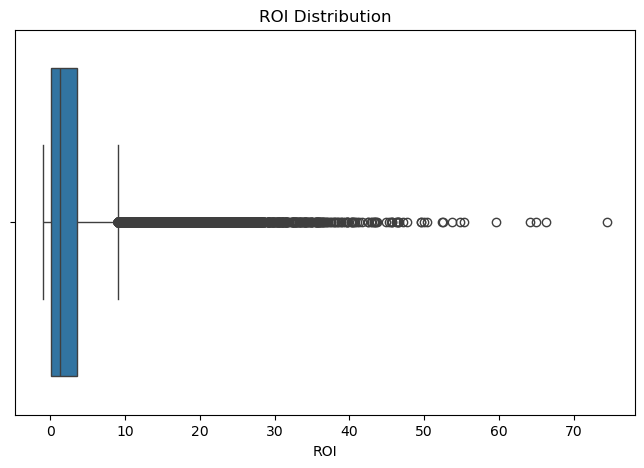

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["ROI"])

plt.title("ROI Distribution")
plt.xlabel("ROI")

plt.show()

In [30]:
df["Date"].head(10)

0    29-04-2025
1    06-04-2025
2    14-01-2025
3    04-06-2025
4    29-12-2024
5    23-09-2024
6    01-09-2024
7    31-05-2025
8    24-03-2025
9    29-04-2025
Name: Date, dtype: object

In [32]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

In [34]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Invalid dates:", df["Date"].isna().sum())
print("Data type:", df["Date"].dtype)

Start date: 2024-07-01 00:00:00
End date: 2025-06-24 00:00:00
Invalid dates: 0
Data type: datetime64[ns]


In [36]:
#checking negaitve values
numeric_cols = [
    "Duration",
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Acquisition_Cost",
    "Engagement_Score"
]

for col in numeric_cols:
    print(f"{col}: {(df[col] < 0).sum()} negative values")

Duration: 0 negative values
Impressions: 0 negative values
Clicks: 0 negative values
Leads: 0 negative values
Conversions: 0 negative values
Revenue: 0 negative values
Acquisition_Cost: 0 negative values
Engagement_Score: 0 negative values


In [38]:
outlier_cols = [
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Acquisition_Cost",
    "ROI",
    "Engagement_Score"
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} potential outliers")

Impressions: 0 potential outliers
Clicks: 311 potential outliers
Leads: 1776 potential outliers
Conversions: 2333 potential outliers
Revenue: 3156 potential outliers
Acquisition_Cost: 4845 potential outliers
ROI: 4081 potential outliers
Engagement_Score: 0 potential outliers


In [42]:
df[[
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Revenue",
    "Acquisition_Cost",
    "ROI"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
Impressions,55555.0,55087.885357,25930.001514,10001.00,32680.000,55182.00,77514.50,100000.00
Clicks,55555.0,4688.070507,3178.686285,202.00,2110.000,3907.00,6688.00,14868.00
Leads,55555.0,1877.271119,1435.636117,56.00,779.000,1481.00,2605.00,8876.00
Conversions,55555.0,1032.866925,862.496788,19.00,400.000,779.00,1414.00,6686.00
Revenue,55555.0,515819.715273,490012.112118,6183.00,177706.000,360436.00,687422.50,4579910.00
Acquisition_Cost,55555.0,377.347068,541.084524,9.08,105.435,207.51,428.58,15473.16
ROI,55555.0,2.713807,4.493380,-0.97,0.040,1.24,3.63,74.42


In [44]:
print("Infinite values:", np.isinf(df[numeric_cols]).sum().sum())

Infinite values: 0


In [46]:
df.dtypes

Campaign_ID                 object
Campaign_Type               object
Target_Audience             object
Duration                     int64
Channel_Used                object
Impressions                  int64
Clicks                       int64
Leads                        int64
Conversions                  int64
Revenue                      int64
Acquisition_Cost           float64
ROI                        float64
Language                    object
Engagement_Score           float64
Customer_Segment            object
Date                datetime64[ns]
dtype: object

In [48]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,2025-04-29
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,2025-04-06
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,2025-01-14
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,2025-06-04
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29


In [50]:
df.to_csv("../data/processed/nykaa_campaign_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
